Data preprocessing

In [20]:
import pandas as pd 
df = pd.read_csv("C:\\Users\\Nitin\\OneDrive\\Desktop\\BTECH 2nd sem\\Diabetes_prediction_AgenticAi\\Dataset\\diabetes_dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
import os
print(os.path.exists("C:\\Users\\Nitin\\OneDrive\\Desktop\\BTECH 2nd sem\\Diabetes_prediction_AgenticAi\\Dataset\\diabetes_dataset.csv"))

True


Text(0.5, 1.0, 'Distribution of Diabetes Outcome')

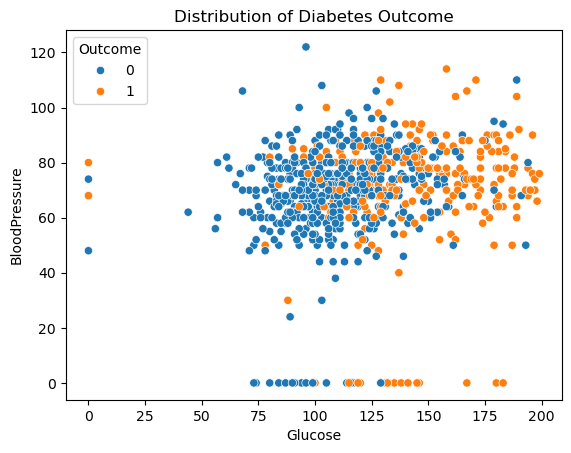

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# sns.countplot(x='Pregnancies', data=df)
sns.scatterplot(x='Glucose', y='BloodPressure', hue='Outcome', data=df, )    
plt.title('Distribution of Diabetes Outcome')

Text(0.5, 1.0, 'Insulin vs SkinThickness by Outcome')

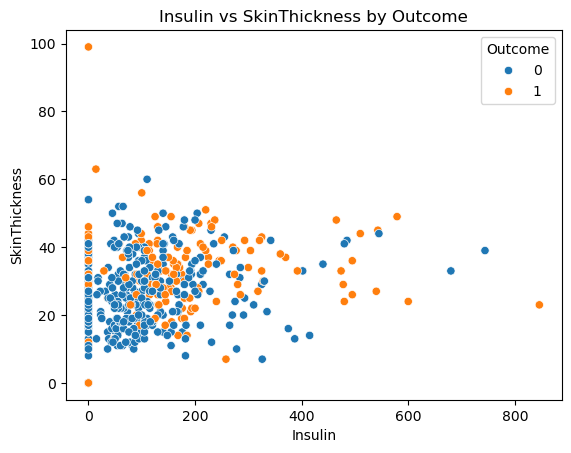

In [23]:
sns.scatterplot(x='Insulin', y='SkinThickness', hue='Outcome', data=df, )    
plt.title('Insulin vs SkinThickness by Outcome')

Text(0.5, 1.0, 'BMI vs Age by Outcome')

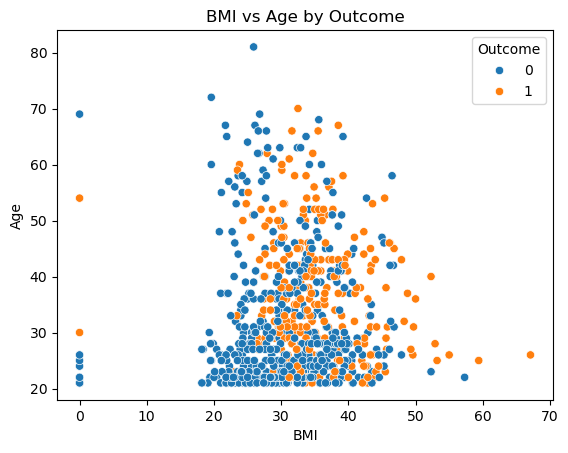

In [24]:
sns.scatterplot(x='BMI', y='Age', hue='Outcome', data=df, )    
plt.title('BMI vs Age by Outcome')

Here we can see the data has zero value that is irrelevent for the model so it reduces the perfornamce of the algorithms so we are now going to fill these value through KNN_imputer
 
1.glucose
2.blood pressure
3.age
4.BMI
5.Insulin
6.SkinThickness

In [25]:
import numpy as np
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

In [26]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

<Axes: ylabel='Insulin'>

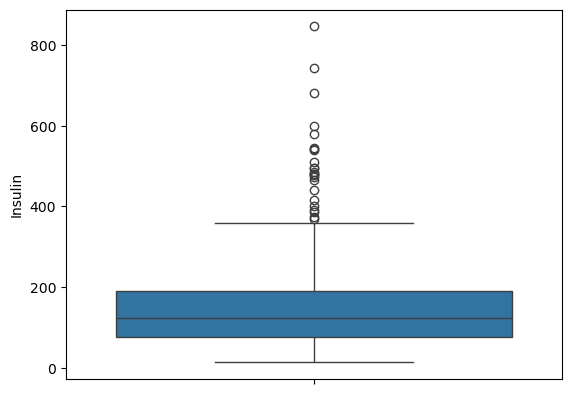

In [27]:
import seaborn as sns
sns.boxplot(df["Insulin"])

now i am filling the missing value via imputer and handeling the edge cases and doing proper data cleaning 

In [28]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[cols_to_fix]= imputer.fit_transform(df[cols_to_fix])

In [29]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [30]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,209.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,73.0,26.6,0.351,31,0
2,8,183.0,64.0,29.4,383.2,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [31]:
# Save preprocessed data
df.to_csv("pima_diabetes_preprocessed.csv", index=False)
print("Preprocessed CSV saved!")

Preprocessed CSV saved!
